# 🛫 Prévision des Retards Aériens — Notebook MLflow
**Projet PPML- FlyOnTime — 6 plus grands aéroports français**


### Configuration & Imports

In [2]:
import pandas as pd
import os
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from pandas.api.types import is_datetime64_any_dtype
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import mlflow

### Connexion MLflow

In [3]:
# --- 1. CONFIGURATION SERVEUR ---
MLFLOW_REMOTE_URI = "https://stoneray-ppml-mlflow.hf.space/"
mlflow.set_tracking_uri(MLFLOW_REMOTE_URI)



### Chargement des données

**Source :** AWS S3 (format Parquet)

**Datasets :**
- `df_train` → données historiques pour l'entraînement
- `df_predict` → données d'avril 2026 pour la prédiction finale

In [4]:
import boto3

# Fonction pour récupérer mes fichiers sur le bucket S3 de l'équipe
def charger_data_s3(chemin_fichier):
    # Setup de la session avec mes accès
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    
    nom_bucket = os.getenv("BUCKET_EQUIPE")
    url_complete = f"s3://{nom_bucket}/{chemin_fichier}"
    
    print(f"Récupération du fichier : {chemin_fichier}...")
    
    
    if chemin_fichier.endswith('.csv'):
        return pd.read_csv(url_complete)
    else:
        return pd.read_parquet(url_complete)

# Chargement depuis S3
df_train = charger_data_s3("datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv")
df_predict = charger_data_s3("datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv")

# Je vérifie le format
print(f"Format Train   : {df_train.shape}")
print(f"Format Predict : {df_predict.shape}")

Récupération du fichier : datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv...


C:\Users\surel\AppData\Local\Temp\ipykernel_8516\744087605.py:19: DtypeWarning: Columns (64,65,67,76,80,82,84,86) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(url_complete)


Récupération du fichier : datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv...
Format Train   : (94378, 96)
Format Predict : (4063, 96)


In [5]:
# Aperçu rapide des colonnes disponibles
print("Colonnes df_train :")
print(df_train.columns.tolist())
print("Colonnes df_predict :")
print(df_predict.columns.tolist())
print("---------------------------")
print("Aperçu df_train :")
df_train.head()


Colonnes df_train :
['flight_date', 'movement_date', 'flight_number', 'airline', 'airport_origin', 'airport_destination', 'terminal_departure', 'terminal_arrival', 'scheduled_departure', 'scheduled_arrival', 'estimated_departure', 'estimated_arrival', 'actual_departure', 'actual_arrival', 'actual_source_departure', 'actual_source_arrival', 'departure_delay_min', 'departure_advance_min', 'arrival_delay_min', 'arrival_advance_min', 'status', 'movement_type', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'cloud_base_dep', 'visibility_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunder

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


### On voit que la première ligne est inutile

In [6]:
print(df_train.iloc[0])
df = df_train.iloc[1:].reset_index(drop=True)
df_predict = df_predict.iloc[1:].reset_index(drop=True)


display(df_train.head())
print("-----------------------------------------------------------------------")
display(df_predict.head())

flight_date                             DATE_GENERATION
movement_date                       2026-04-17 03:31:48
flight_number                                       NaN
airline                                             NaN
airport_origin                                      NaN
                                           ...         
nombre_departs_destination                          NaN
nombre_arrivees_destination                         NaN
somme_depart_arrivee_destination                    NaN
congestion_destination                              NaN
retard arrivée                                      NaN
Name: 0, Length: 96, dtype: object


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


-----------------------------------------------------------------------


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2026-04-17,2026-04-17,AF 6212,Air France,ORY,NCE,2,2,2026-04-17 12:35+02:00,2026-04-17 14:05+02:00,...,NaN,550.0,540.0,1090.0,1.0,179.0,177.0,356.0,0.0,0.0
1,2026-04-17,2026-04-17,AF 7300,Air France,CDG,NCE,2F,2,2026-04-17 06:45+02:00,2026-04-17 08:15+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
2,2026-04-17,2026-04-17,AF 7301,Air France,NCE,CDG,2,2F,2026-04-17 09:05+02:00,2026-04-17 10:40+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0
3,2026-04-17,2026-04-17,AF 7302,Air France,CDG,NCE,2F,2,2026-04-17 07:15+02:00,2026-04-17 08:50+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
4,2026-04-17,2026-04-17,AF 7303,Air France,NCE,CDG,2,2F,2026-04-17 09:45+02:00,2026-04-17 11:20+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0


### --- Vérification des doublons ---
Normalement, un numéro de vol sur une même journée, c'est unique. 
Si j'en ai plusieurs, c'est qu'il y a un bug dans l'extraction.

In [7]:
# --- VÉRIFICATION DES DOUBLONS (Train & Predict) ---

# 1. Check sur les données d'entraînement
doublons_train = df_train[df_train.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"⚠️ Doublons dans le Train : {len(doublons_train)}")

# 2. Check sur les données futures (histoire d'être sûr)
doublons_predict = df_predict[df_predict.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"🔍 Doublons dans le Predict : {len(doublons_predict)}")

# Si j'ai un doute sur le futur, je regarde
if len(doublons_predict) > 0:
    print("Aperçu des doublons 'Futur' :")
    display(doublons_predict.sort_values(by=["flight_number", "flight_date"]).head(6))

⚠️ Doublons dans le Train : 1572
🔍 Doublons dans le Predict : 92
Aperçu des doublons 'Futur' :


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
162,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 12:35+02:00,2026-04-17 13:45+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
163,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 17:00+02:00,2026-04-17 18:10+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
1360,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 12:35+02:00,2026-04-19 13:45+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1361,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 16:40+02:00,2026-04-19 17:50+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1924,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 12:35+02:00,2026-04-20 13:45+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0
1925,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 17:00+02:00,2026-04-20 18:10+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0


Nous avons identifié que les doublons apparents ne correspondent pas à des escales, mais à deux lignes complémentaires décrivant un même vol : l’une pour le départ et l’autre pour l’arrivée. Il ne faut donc pas supprimer ces lignes ni les traiter séparément, car cela entraînerait une perte d’information et un biais dans le modèle. La bonne approche consiste à regrouper ces lignes pour reconstruire un vol complet en une seule observation, en combinant les informations de départ et d’arrivée (par exemple via un groupby et des agrégations adaptées).

In [8]:
# --- ANALYSE DES DOUBLONS (TRAIN & PREDICT) ---

# Définition des colonnes qui identifient un vol unique
cles_doublons = ["flight_number", "flight_date", "airport_origin", "airport_destination"]

# 1. Analyse pour le TRAIN
masque_train = df_train.duplicated(subset=cles_doublons, keep=False)
vols_doubles_train = df_train[masque_train]
vols_uniques_train = df_train[~masque_train]

# 2. Analyse pour le PREDICT
masque_predict = df_predict.duplicated(subset=cles_doublons, keep=False)
vols_doubles_predict = df_predict[masque_predict]
vols_uniques_predict = df_predict[~masque_predict]

# --- VÉRIFICATION DES THÉORIES ---
print(f"📊 TRAIN   : {len(vols_doubles_train)} lignes en doublons ({len(vols_doubles_train)//2} vols)")
print(vols_doubles_train["movement_type"].value_counts())

print(f"\n📊 PREDICT : {len(vols_doubles_predict)} lignes en doublons ({len(vols_doubles_predict)//2} vols)")
print(vols_doubles_predict["movement_type"].value_counts())

# Si les volumes Departure/Arrival sont quasi identiques, on confirme la structure "vols coupés en deux"

📊 TRAIN   : 1480 lignes en doublons (740 vols)
movement_type
departure    741
arrival      739
Name: count, dtype: int64

📊 PREDICT : 80 lignes en doublons (40 vols)
movement_type
departure    47
arrival      33
Name: count, dtype: int64


Il arrive que certain avions fassent plusieurs rotations par jour 
Quand on "recolle" le vol, on crée une seule ligne ultra-complète.
Avant (2 lignes) :
Ligne 1 : Vol AF1234 | Départ Paris | Vent 20km/h
Ligne 2 : Vol AF1234 | Arrivée Nice | Pluie | Retard 15min
Après (1 vol recollé) : Ligne Unique : Vol AF1234 | Départ Paris (Vent 20km/h) | Arrivée Nice (Pluie) | Retard 15min

In [9]:
# --- LA RÉPARATION (TRAIN & PREDICT) ---

def reparer_vols(df):
    # 1. Nettoyage de la ligne technique et conversion dates
    df = df.iloc[1:].reset_index(drop=True)
    dates_cols = ["flight_date", "scheduled_departure", "scheduled_arrival"]
    for c in dates_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    cles = ["flight_number", "flight_date", "airport_origin", "airport_destination"]
    masque = df.duplicated(subset=cles, keep=False)
    
    vols_solo = df[~masque].copy()
    vols_a_reparer = df[masque].copy()
    
    dep = vols_a_reparer[vols_a_reparer["movement_type"] == "departure"].sort_values("scheduled_departure")
    arr = vols_a_reparer[vols_a_reparer["movement_type"] == "arrival"].sort_values("scheduled_arrival")

    dep["n_vol"] = dep.groupby(cles).cumcount()
    arr["n_vol"] = arr.groupby(cles).cumcount()
    
    df_reconstruit = pd.merge(dep, arr, on=cles + ["n_vol"], suffixes=('_dep', '_arr'))
    
    return pd.concat([vols_solo, df_reconstruit], ignore_index=True)

df_train_final = reparer_vols(df_train)
df_predict_final = reparer_vols(df_predict)

# --- BILAN ---
print(f"✅ TRAIN   : {len(df_train_final)} vols prêts.")
print(f"✅ PREDICT : {len(df_predict_final)} vols prêts.")

C:\Users\surel\AppData\Local\Temp\ipykernel_8516\2513086950.py:9: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors="coerce")
C:\Users\surel\AppData\Local\Temp\ipykernel_8516\2513086950.py:9: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors="coerce")


✅ TRAIN   : 93584 vols prêts.
✅ PREDICT : 4014 vols prêts.


### --- BILAN DE SANTÉ FINAL ---
 Je rajoute l'heure de départ prévue ('scheduled_departure') dans le filtre pour prendre en compte l'heure de départ.

In [10]:
colonnes_cles = ['flight_number', 'flight_date', 'scheduled_departure']
 
nb_train = df_train_final.duplicated(subset=colonnes_cles).sum()
nb_predict = df_predict_final.duplicated(subset=colonnes_cles).sum()
print(f"Bilan de santé Train   : {nb_train} vrais doublons.")
print(f"Bilan de santé Predict : {nb_predict} vrais doublons.")
if nb_train + nb_predict == 0:
    print("\n✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.")
else:
    print("\n⚠️ Attention, il reste encore des rescapés à checker.")

Bilan de santé Train   : 0 vrais doublons.
Bilan de santé Predict : 0 vrais doublons.

✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.


In [11]:
#%who DataFrame
#on travaille désormais sur df_train_final et df_predict_final, qui sont nos datasets réparés et prêts pour l'analyse et le modeling.

### On s'occupe des NaN 🫓

In [12]:
print(f"📏 Dimensions du TRAIN   : {df_train_final.shape} (Lignes, Colonnes)")
print(f"📏 Dimensions du PREDICT : {df_predict_final.shape} (Lignes, Colonnes)")

📏 Dimensions du TRAIN   : (93584, 281) (Lignes, Colonnes)
📏 Dimensions du PREDICT : (4014, 281) (Lignes, Colonnes)


In [13]:
def check_missing(df, name):
    print(f"\n🔍 ANALYSE : {name}")
    stats = (df.isna().mean() * 100).sort_values(ascending=False)
    stats_filtered = stats[stats > 0]
    if not stats_filtered.empty:
        print(stats_filtered.head(30))
    else:
        print("✅ Propre comme un sou neuf !")

check_missing(df_train_final, "TRAIN")
check_missing(df_predict_final, "PREDICT")


🔍 ANALYSE : TRAIN
Label Jour Ferié_arr      100.000000
cloud_base_arr_arr        100.000000
visibility_arr_arr        100.000000
visibility_dep_arr        100.000000
cloud_base_dep_arr        100.000000
visibility_arr_dep        100.000000
Label Jour Ferié_dep      100.000000
LABEL_TOULOUSE            100.000000
LABEL_TOULOUSE_arr        100.000000
cloud_base_dep_dep        100.000000
visibility_dep_dep        100.000000
cloud_base_arr            100.000000
LABEL_TOULOUSE_dep        100.000000
cloud_base_dep            100.000000
visibility_dep            100.000000
cloud_base_arr_dep        100.000000
visibility_arr            100.000000
LABEL_CDG_arr              99.998931
LABEL_CDG_dep              99.998931
LABEL_ORLY_arr             99.995726
LABEL_ORLY_dep             99.995726
LABEL_MARSEILLE_dep        99.976492
LABEL_MARSEILLE_arr        99.976492
LABEL_LYON_arr             99.973286
LABEL_LYON_dep             99.973286
LABEL_NICE_dep             99.961532
LABEL_NICE_arr     

In [14]:
def purger_et_voir(df, nom_dataset):
    print(f"\n--- 🗑️ NETTOYAGE : {nom_dataset} ---")
    colonnes_avant = set(df.columns)
    cles = ["flight_number", "flight_date", "airport_origin", "airport_destination"]
    # On protège tout ce qui contient "delay" ou "retard"
    mots_cles_proteges = ['delay', 'retard', 'target'] 
    
    cols_a_garder = [c for c in df.columns if 
                     c.endswith(('_dep', '_arr')) or 
                     c in cles or 
                     any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_filtre = df[cols_a_garder].copy()
    
    seuil = 0.6 
    taux_nan = df_filtre.isnull().mean()
    cols_trop_vides = [c for c in taux_nan[taux_nan > seuil].index 
                       if not any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_final = df_filtre.drop(columns=cols_trop_vides)
    
    fantômes = colonnes_avant - set(cols_a_garder)
    print(f"👻 {len(fantômes)} colonnes sans suffixe supprimées.")
    print(f"🏜️ {len(cols_trop_vides)} colonnes > {seuil*100}% vides supprimées.")
    print(f"🛡️ Colonnes de retard préservées : {[c for c in df_final.columns if any(mot in c.lower() for mot in mots_cles_proteges)]}")
    
    return df_final.ffill().bfill()

# On relance
df_train_final = purger_et_voir(df_train_final, "TRAIN")
df_predict_final = purger_et_voir(df_predict_final, "PREDICT")


--- 🗑️ NETTOYAGE : TRAIN ---
👻 48 colonnes sans suffixe supprimées.
🏜️ 182 colonnes > 60.0% vides supprimées.
🛡️ Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_delay_min_arr', 'retard arrivée_arr']

--- 🗑️ NETTOYAGE : PREDICT ---
👻 48 colonnes sans suffixe supprimées.
🏜️ 182 colonnes > 60.0% vides supprimées.
🛡️ Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_delay_min_arr', 'retard arrivée_arr']


In [15]:
def scan_total_vides(df, name):
    print(f"\n🕵️ SCAN COMPLET : {name}")
    nans = df.isna().sum().sum()
    
    vides = (df == "").sum().sum()
    placeholders = ["none", "null", "unknown", "missing", "nan", "undefined"]
    text_vides = df.apply(lambda x: x.astype(str).str.lower().isin(placeholders)).sum().sum()
    infinites = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

    print(f"  - NaNs classiques      : {nans}")
    print(f"  - Textes vides ('' )   : {vides}")
    print(f"  - Mots-clés 'vides'    : {text_vides}")
    print(f"  - Valeurs infinies     : {infinites}")

scan_total_vides(df_train_final, "TRAIN")
scan_total_vides(df_predict_final, "PREDICT")


🕵️ SCAN COMPLET : TRAIN
  - NaNs classiques      : 0
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 0
  - Valeurs infinies     : 0

🕵️ SCAN COMPLET : PREDICT
  - NaNs classiques      : 24084
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 24084
  - Valeurs infinies     : 0


In [16]:
print("Columnes Train:", list(df_train_final.columns))
print("\nColumnes Predict:", list(df_predict_final.columns))
 
diff = set(df_train_final.columns) ^ set(df_predict_final.columns)
print(f"\n✅ Identiques : {not diff}" if not diff else f"⚠️ Différences : {diff}")

Columnes Train: ['flight_date', 'flight_number', 'airport_origin', 'airport_destination', 'departure_delay_min', 'arrival_delay_min', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr', 'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr', 'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr', 'has_precipitation_arr', 'fog_arr', 'humidity_arr', 'temperature_2m_arr', 'cloud_cover_arr', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_

In [35]:
df_train_final.columns

Index(['flight_date', 'flight_number', 'airport_origin', 'airport_destination',
       'departure_delay_min', 'arrival_delay_min', 'time_dep',
       'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep',
       'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep',
       'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep',
       'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep',
       'has_precipitation_dep', 'fog_dep', 'humidity_dep',
       'temperature_2m_dep', 'cloud_cover_dep', 'time_arr',
       'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr',
       'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr',
       'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr',
       'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr',
       'has_precipitation_arr', 'fog_arr', 'humidity_arr',
       'temperature_2m_arr', 'cloud_cover_arr', 'retard arrivée',
       'departure_delay_min_d

### On définit la notion de retard

In [ ]:
# y_reg_arr = df_train_final['arrival_delay_min'].clip(lower=0)   # Cible : retard à l'arrivée
# y_reg_dep = df_train_final['departure_delay_min'].clip(lower=0) # Cible : retard au départ

# print(f"📊 Moyenne retard Arrivée : {y_reg_arr.mean():.2f} min")
# print(f"📊 Moyenne retard Départ  : {y_reg_dep.mean():.2f} min")

📊 Moyenne retard Arrivée : 15.43 min
📊 Moyenne retard Départ  : 23.04 min


In [34]:
%who

CONF	 ColumnTransformer	 MLFLOW_REMOTE_URI	 MON_HUB	 OneHotEncoder	 OrdinalEncoder	 PRENOM	 Pipeline	 RandomForestClassifier	 
RandomForestRegressor	 SimpleImputer	 X	 X_p	 X_predict	 X_predict_final	 X_test	 X_train	 accuracy_score	 
airports	 ax1	 boto3	 c_entrainement	 cat_cols	 cat_cols_entrainement	 charger_data_s3	 check_missing	 classification_report	 
clear_output	 cles_doublons	 col	 col_detectee	 col_h	 colonnes_cles	 cols_base	 cols_dates	 cols_existantes	 
cols_finales	 cols_meteo	 confusion_matrix	 df	 df_predict	 df_predict_final	 df_resultats	 df_train	 df_train_final	 
diff	 display	 doublons_predict	 doublons_train	 dropdown	 dt	 encoder	 explainer	 f1_score	 
features	 fig	 filtrer_vols	 imp_arr	 indices_test	 is_datetime64_any_dtype	 mae_arr	 masque_predict	 masque_train	 
mean_absolute_error	 mean_squared_error	 metrics	 mlflow	 model	 mouvement_test	 nb_predict	 nb_retards	 nb_train	 
np	 os	 pd	 plt	 precision_score	 preds	 purger_et_voir	 r2_arr	 r2_score	 
recal

### MODELING

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, r2_score
# import mlflow
# import mlflow.sklearn

# PRENOM = "Ludo"
# CONF = {
#     "exp": "FlyOnTime_Regressor",
#     "run": "RandomForest_Final_Clean",
#     "reg": "RF_Arrival_Model_Ludo",
#     "params": {"n_estimators": 100, "max_depth": 12, "random_state": 42}
# }

# mlflow.set_experiment(CONF["exp"])
# df_train_final.columns = df_train_final.columns.str.strip()

# cols_dates = ['scheduled_departure', 'scheduled_arrival', 'flight_date']
# cols_base = ['flight_number', 'airport_origin', 'airport_destination']

# cols_meteo = [c for c in df_train_final.columns if c.endswith(('_dep', '_arr')) 
#               and not any(x in c.lower() for x in ['retard', 'delay'])]

# features = [c for c in (cols_base + cols_dates) if c in df_train_final.columns] + cols_meteo
# X = df_train_final[features].copy()

# for col in [c for c in cols_dates if c in X.columns]:
#     dt = pd.to_datetime(X[col], utc=True, errors='coerce')
#     X[f"{col}_month"], X[f"{col}_day"], X[f"{col}_hour"] = dt.dt.month, dt.dt.dayofweek, dt.dt.hour
#     if 'scheduled' in col: 
#         X[f"{col}_min"] = dt.dt.minute
#     X = X.drop(columns=[col])

# cat_cols = X.select_dtypes('object').columns
# if not cat_cols.empty:
#     encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
#     X[cat_cols] = encoder.fit_transform(X[cat_cols].astype(str))

# y = df_train_final['arrival_delay_min'].clip(lower=0)
# X_train, X_test, y_train, y_test = train_test_split(X.fillna(-1), y, test_size=0.2, random_state=42)

# with mlflow.start_run(run_name=CONF["run"]):
#     mlflow.set_tags({"Prénom": PRENOM, "version": "clean_no_leaks"})
#     mlflow.log_params(CONF["params"])

#     model = RandomForestRegressor(**CONF["params"], n_jobs=-1).fit(X_train, y_train)
#     y_pred = model.predict(X_test)
    
#     metrics = {"mae": mean_absolute_error(y_test, y_pred), "r2": r2_score(y_test, y_pred)}
#     mlflow.log_metrics(metrics)
    
#     mlflow.sklearn.log_model(model, "model", registered_model_name=CONF["reg"])

#     print(f"✅ Entraînement terminé sur {len(X.columns)} colonnes.")
#     print(f"📋 Liste finale : {list(X.columns)}")
#     print(f"📊 MAE: {metrics['mae']:.2f} | R2: {metrics['r2']:.2f}")

2026/04/20 18:06:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 18:06:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'RF_Arrival_Model_Ludo' already exists. Creating a new version of this model...
2026/04/20 18:07:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RF_Arrival_Model_Ludo, version 3
Created version '3' of model 'RF_Arrival_Model_Ludo'.


✅ Entraînement terminé sur 44 colonnes.
📋 Liste finale : ['flight_number', 'airport_origin', 'airport_destination', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr', 'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr', 'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr', 'has_precipitation_arr', 'fog_arr', 'humidity_arr', 'temperature_2m_arr', 'cloud_cover_arr', 'flight_date_month', 'flight_date_day', 'flight_date_hour']
📊 MAE: 9.81 | R2: 0.66
🏃 View run RandomForest_Final_Clean at: https://stoneray-ppml-m

In [19]:
# print(f"📊 STRUCTURE DES DONNÉES :")
# print(f"🔹 Train set : {X_train.shape[0]} lignes | {X_train.shape[1]} colonnes")
# print(f"🔹 Test set  : {X_test.shape[0]} lignes | {X_test.shape[1]} colonnes")

# if list(X_train.columns) == list(X_test.columns):
#     print("✅ Alignement parfait : Les colonnes de Train et Test sont identiques.")
#     print(f"📋 Liste des colonnes utilisées :\n{list(X_train.columns)}")
# else:
#     print("⚠️ ATTENTION : Décalage détecté entre les colonnes de Train et Test !")

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor # Le nouveau moteur
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow
import mlflow.xgboost

PRENOM = "Ludo"
CONF = {
    "exp": "FlyOnTime_XGBoost",
    "run": "XGBoost_Regressor_Final",
    "reg": "XGB_Arrival_Model_Ludo",
    "params": {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "n_jobs": -1
    }
}

mlflow.set_experiment(CONF["exp"])
# df_train_final.columns = df_train_final.columns.str.strip()
# # cols_dates = ['scheduled_departure', 'scheduled_arrival', 'flight_date']
# # cols_base = ['flight_number', 'airport_origin', 'airport_destination']
# # cols_meteo = [c for c in df_train_final.columns if c.endswith(('_dep', '_arr')) 
# #               and not any(x in c.lower() for x in ['retard', 'delay'])]

# # features = [c for c in (cols_base + cols_dates) if c in df_train_final.columns] + cols_meteo
X = df_train_final[features].copy()

for col in [c for c in cols_dates if c in X.columns]:
    dt = pd.to_datetime(X[col], utc=True, errors='coerce')
    X[f"{col}_month"], X[f"{col}_day"], X[f"{col}_hour"] = dt.dt.month, dt.dt.dayofweek, dt.dt.hour
    if 'scheduled' in col: X[f"{col}_min"] = dt.dt.minute
    X = X.drop(columns=[col])

cat_cols = X.select_dtypes('object').columns
if not cat_cols.empty:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[cat_cols] = encoder.fit_transform(X[cat_cols].astype(str))

y = df_train_final['arrival_delay_min'].clip(lower=0)
X_train, X_test, y_train, y_test = train_test_split(X.fillna(-1), y, test_size=0.2, random_state=42)

with mlflow.start_run(run_name=CONF["run"]):
    mlflow.set_tags({"Prénom": PRENOM, "algo": "XGBoost"})
    mlflow.log_params(CONF["params"])

    model = XGBRegressor(**CONF["params"])
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    metrics = {"mae": mean_absolute_error(y_test, y_pred), "r2": r2_score(y_test, y_pred)}
    mlflow.log_metrics(metrics)
    
    mlflow.xgboost.log_model(model, "model", registered_model_name=CONF["reg"])

    print(f"🚀 XGBoost entraîné sur {len(X.columns)} colonnes.")
    print(f"📊 MAE: {metrics['mae']:.2f} | R2: {metrics['r2']:.2f}")

2026/04/20 19:14:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'XGB_Arrival_Model_Ludo' already exists. Creating a new version of this model...
2026/04/20 19:14:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB_Arrival_Model_Ludo, version 2
Created version '2' of model 'XGB_Arrival_Model_Ludo'.


🚀 XGBoost entraîné sur 44 colonnes.
📊 MAE: 9.79 | R2: 0.66
🏃 View run XGBoost_Regressor_Final at: https://stoneray-ppml-mlflow.hf.space/#/experiments/14/runs/2733d470188d4ce7b874caf5835fdf93
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/14


In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

# On utilise les noms de variables définis dans ta cellule d'entraînement précédente
indices_test = X_test.index
mouvement_test = np.where(df_train_final.loc[indices_test, 'airport_origin'] == 'CDG', '🛫 DÉPART', '🛬 ARRIVÉE')

# Attention : ici on utilise 'model' car c'est le nom dans ta cellule d'avant
preds = model.predict(X_test)

resultats_comparaison = pd.DataFrame({
    'Mouvement': mouvement_test,
    'Réel': y_test.values, # On utilise y_test qui vient du split
    'Prédit': preds.round(1)
}, index=indices_test)

resultats_comparaison['Erreur'] = (resultats_comparaison['Réel'] - resultats_comparaison['Prédit']).round(2)

print("📊 ANALYSE DES PRÉDICTIONS D'ARRIVÉE (Version Clean)")
display(resultats_comparaison.head(100))

mae_arr = mean_absolute_error(resultats_comparaison['Réel'], resultats_comparaison['Prédit'])
r2_arr = r2_score(resultats_comparaison['Réel'], resultats_comparaison['Prédit'])

print(f"\n💡 PERFORMANCE DU MODÈLE :")
print(f"👉 Erreur Moyenne Absolue (MAE) : {mae_arr:.2f} min")
print(f"👉 Score R² (Précision)         : {r2_arr:.2f}")

📊 ANALYSE DES PRÉDICTIONS D'ARRIVÉE (Version Clean)


,Mouvement,Réel,Prédit,Erreur
58180,🛫 DÉPART,0.0,1.400000,-1.4
8959,🛬 ARRIVÉE,12.0,4.700000,7.3
73699,🛬 ARRIVÉE,0.0,2.900000,-2.9
39620,🛫 DÉPART,16.0,27.299999,-11.3
73154,🛫 DÉPART,39.0,20.500000,18.5
...,...,...,...,...
82885,🛬 ARRIVÉE,0.0,2.700000,-2.7
24327,🛫 DÉPART,35.0,27.200001,7.8
92537,🛬 ARRIVÉE,0.0,-0.300000,0.3
24338,🛬 ARRIVÉE,0.0,-1.300000,1.3



💡 PERFORMANCE DU MODÈLE :
👉 Erreur Moyenne Absolue (MAE) : 9.79 min
👉 Score R² (Précision)         : 0.66


In [39]:
# juste les atterissages arrivées
resultats_uniquement_arrivees = resultats_comparaison[resultats_comparaison['Mouvement'] == '🛬 ARRIVÉE']

print("📊 COMPARAISON DES ATTERRISSAGES UNIQUEMENT")
display(resultats_uniquement_arrivees.head(10))

📊 COMPARAISON DES ATTERRISSAGES UNIQUEMENT


,Mouvement,Réel,Prédit,Erreur
8959,🛬 ARRIVÉE,12.0,4.700000,7.3
73699,🛬 ARRIVÉE,0.0,2.900000,-2.9
52862,🛬 ARRIVÉE,0.0,7.200000,-7.2
38594,🛬 ARRIVÉE,31.0,6.300000,24.7
4063,🛬 ARRIVÉE,46.0,18.600000,27.4
29744,🛬 ARRIVÉE,4.0,19.700001,-15.7
12732,🛬 ARRIVÉE,0.0,9.700000,-9.7
20381,🛬 ARRIVÉE,23.0,17.000000,6.0
75229,🛬 ARRIVÉE,14.0,11.800000,2.2
20331,🛬 ARRIVÉE,27.0,12.000000,15.0


C:\Users\surel\AppData\Local\Temp\ipykernel_8516\3770974732.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_arr.head(20), palette='viridis', ax=ax1)


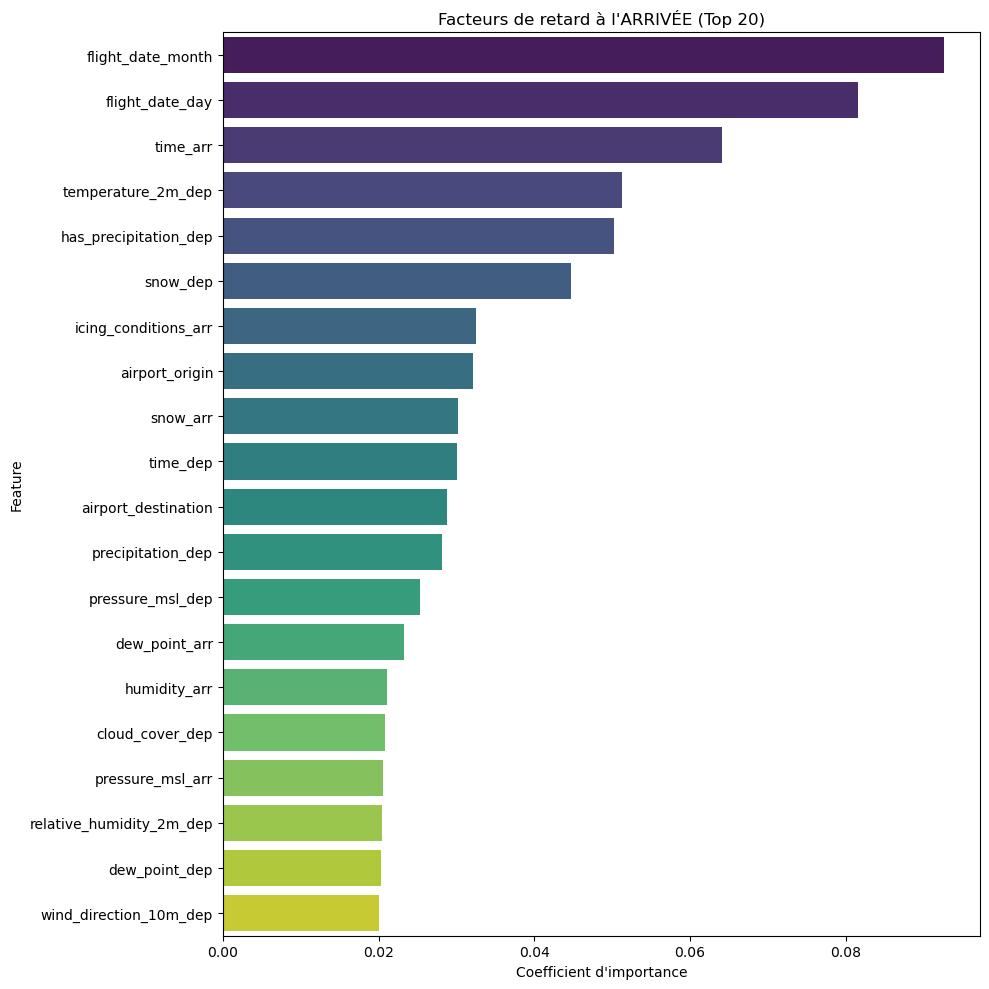

In [45]:
imp_arr = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 10)) 

sns.barplot(x='Importance', y='Feature', data=imp_arr.head(20), palette='viridis', ax=ax1)
ax1.set_title("Facteurs de retard à l'ARRIVÉE (Top 20)")
ax1.set_xlabel("Coefficient d'importance")

plt.tight_layout()
plt.show()

🧬 ANALYSE DE L'IMPORTANCE DES FEATURES (SHAP)


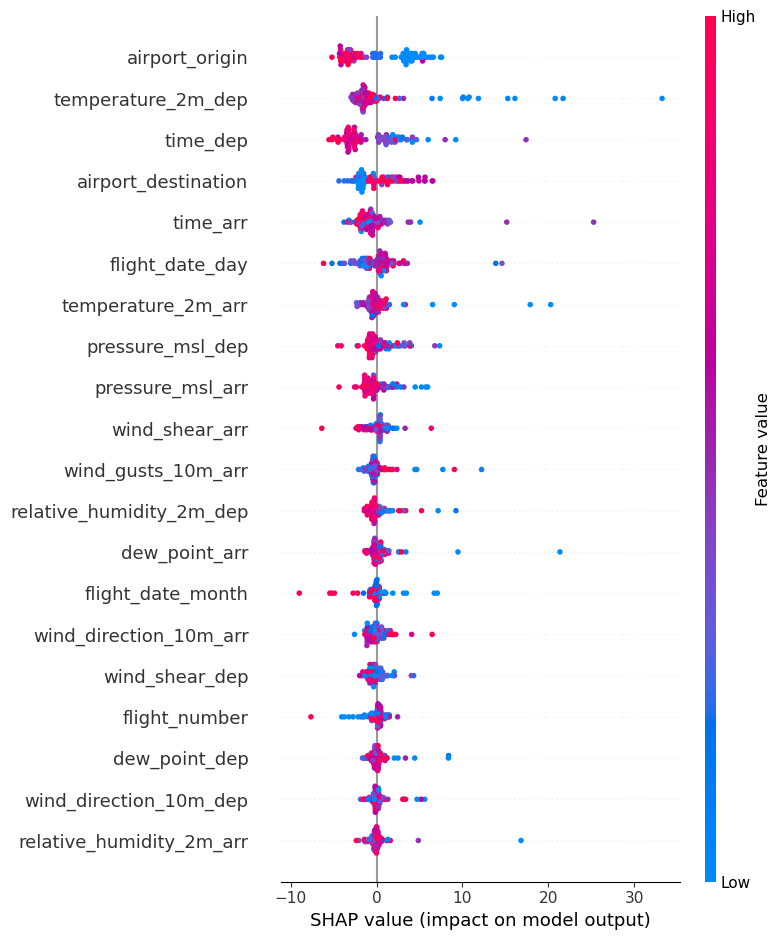

In [41]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test.iloc[:100])

print("🧬 ANALYSE DE L'IMPORTANCE DES FEATURES (SHAP)")
shap.summary_plot(shap_values, X_test.iloc[:100])

# Prédire le futur

In [42]:
import pandas as pd
import numpy as np

df_predict_final.columns = df_predict_final.columns.str.strip()
MON_HUB = 'CDG'

X_predict = df_predict_final.copy()
for col in X_predict.columns:
    if pd.api.types.is_datetime64_any_dtype(X_predict[col]) or X_predict[col].dtype == 'object':
        try:
            temp_date = pd.to_datetime(X_predict[col], utc=True, errors='coerce')
            X_predict[f"{col}_month"] = temp_date.dt.month
            X_predict[f"{col}_day"] = temp_date.dt.dayofweek
            X_predict[f"{col}_hour"] = temp_date.dt.hour
          
            if 'scheduled' in col.lower():
                X_predict[f"{col}_min"] = temp_date.dt.minute
        except:
            continue

cat_cols_entrainement = list(encoder.feature_names_in_)
for col in cat_cols_entrainement:
    if col not in X_predict.columns:
        X_predict[col] = "unknown"

X_predict[cat_cols_entrainement] = encoder.transform(X_predict[cat_cols_entrainement].astype(str))

X_predict_final = X_predict.reindex(columns=X_train.columns, fill_value=-1)
X_predict_final = X_predict_final.apply(pd.to_numeric, errors='coerce').fillna(-1)

df_resultats = df_predict_final.copy()
df_resultats["Retard_Prévu"] = model.predict(X_predict_final).round(1)

df_resultats["Mouvement"] = np.where(df_resultats['airport_origin'] == MON_HUB, "🛫 DÉPART", "🛬 ARRIVÉE")

col_h = [c for c in df_resultats.columns if 'scheduled_departure' in c.lower()]
df_resultats["Heure"] = pd.to_datetime(df_resultats[col_h[0]], errors='coerce').dt.strftime('%H:%M') if col_h else "N/A"

df_resultats["Statut"] = np.where(df_resultats["Retard_Prévu"] > 15, "⚠️ RETARD", "✅ À L'HEURE")

cols_finales = ['Mouvement', 'flight_date', 'Heure', 'flight_number', 'Retard_Prévu', 'Statut']
cols_existantes = [c for c in cols_finales if c in df_resultats.columns]

print("✨ Pipeline terminé. Affichage des plus gros retards prédits :")
display(df_resultats[cols_existantes].sort_values('Retard_Prévu', ascending=False).head(20))

C:\Users\surel\AppData\Local\Temp\ipykernel_8516\848719560.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_date = pd.to_datetime(X_predict[col], utc=True, errors='coerce')
C:\Users\surel\AppData\Local\Temp\ipykernel_8516\848719560.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_date = pd.to_datetime(X_predict[col], utc=True, errors='coerce')
C:\Users\surel\AppData\Local\Temp\ipykernel_8516\848719560.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_date = pd.to_datetime(X_predict[col], utc=True, errors='coerce')
C:\Users\surel\AppData\Local\Temp\

✨ Pipeline terminé. Affichage des plus gros retards prédits :


,Mouvement,flight_date,Heure,flight_number,Retard_Prévu,Statut
1208,🛬 ARRIVÉE,2026-04-19,N/A,AF 7329,79.699997,⚠️ RETARD
1439,🛬 ARRIVÉE,2026-04-19,N/A,EC 4532,73.599998,⚠️ RETARD
1198,🛬 ARRIVÉE,2026-04-19,N/A,AF 7319,72.199997,⚠️ RETARD
2916,🛫 DÉPART,2026-04-22,N/A,AF 7400,69.800003,⚠️ RETARD
1180,🛬 ARRIVÉE,2026-04-19,N/A,AF 7301,68.900002,⚠️ RETARD
1700,🛬 ARRIVÉE,2026-04-19,N/A,U2 4532,68.000000,⚠️ RETARD
2918,🛫 DÉPART,2026-04-22,N/A,AF 7402,65.199997,⚠️ RETARD
1565,🛬 ARRIVÉE,2026-04-19,N/A,MU 1514,58.900002,⚠️ RETARD
1538,🛬 ARRIVÉE,2026-04-19,N/A,MK 9081,58.900002,⚠️ RETARD
3468,🛫 DÉPART,2026-04-23,N/A,AF 7400,58.500000,⚠️ RETARD


In [ ]:
print(f"Retard max prédit : {df_resultats['Retard_Prévu'].max()} min")
print(f"Retard moyen prédit : {df_resultats['Retard_Prévu'].mean()} min")
nb_retards = len(df_resultats[df_resultats['Retard_Prévu'] > 15])
print(f"Nombre de vols prédits avec > 15min de retard : {nb_retards}")

Retard max prédit : 79.69999694824219 min
Retard moyen prédit : 26.813053131103516 min
Nombre de vols prédits avec > 15min de retard : 3399


### VISUEL STYLE AEROPORT

In [44]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np

df_predict_final.columns = df_predict_final.columns.str.strip()

X_p = df_predict_final.copy()
for col in X_p.columns:
    if pd.api.types.is_datetime64_any_dtype(X_p[col]) or X_p[col].dtype == 'object':
        try:
            t_date = pd.to_datetime(X_p[col], utc=True, errors='coerce')
            X_p[f"{col}_month"] = t_date.dt.month
            X_p[f"{col}_day"] = t_date.dt.dayofweek
            X_p[f"{col}_hour"] = t_date.dt.hour
            # CRUCIAL : Extraction des minutes comme à l'entraînement
            if 'scheduled' in col.lower():
                X_p[f"{col}_min"] = t_date.dt.minute
        except: continue

c_entrainement = list(encoder.feature_names_in_)
for col in c_entrainement:
    if col not in X_p.columns:
        X_p[col] = "unknown"

X_p[c_entrainement] = encoder.transform(X_p[c_entrainement].astype(str))

X_predict_final = X_p.reindex(columns=X_train.columns, fill_value=-1)
X_predict_final = X_predict_final.apply(pd.to_numeric, errors='coerce').fillna(-1)

airports = sorted(pd.concat([df_predict_final['airport_origin'], 
                            df_predict_final['airport_destination']]).unique())

dropdown = widgets.Dropdown(
    options=airports,
    value='CDG' if 'CDG' in airports else airports[0],
    description='📍 Aéroport :',
)

def filtrer_vols(aeroport_hub):
    clear_output(wait=True)
    display(dropdown) 
    
    masque = (df_predict_final['airport_origin'] == aeroport_hub) | (df_predict_final['airport_destination'] == aeroport_hub)
    df_local = df_predict_final[masque].copy()
    X_local = X_predict_final[masque]
    
    if df_local.empty:
        print(f"📭 Aucun vol trouvé pour {aeroport_hub}")
        return

    # CORRECTION : On utilise 'model' au lieu de 'model_reg_arr'
    df_local["Retard_Prévu"] = model.predict(X_local).round(1)

    df_local["Mouvement"] = np.where(df_local['airport_origin'] == aeroport_hub, "🛫 DÉPART", "🛬 ARRIVÉE")

    c_h = [c for c in df_local.columns if 'scheduled_departure' in c.lower()]
    if c_h:
        df_local["Heure"] = pd.to_datetime(df_local[c_h[0]], utc=True, errors='coerce').dt.strftime('%H:%M')
    else:
        df_local["Heure"] = "N/A"

    df_local["Statut"] = np.where(df_local["Retard_Prévu"] > 15, "⚠️ RETARD", "✅ À L'HEURE")

    cols = ['Mouvement', 'flight_date', 'Heure', 'flight_number', 'Retard_Prévu', 'Statut']
    df_aff = df_local[[c for c in cols if c in df_local.columns]].fillna('-')
    
    print(f"\n✈️  TABLEAU D'AFFICHAGE : {aeroport_hub}")
    display(df_aff.sort_values('Heure'))

widgets.interactive(filtrer_vols, aeroport_hub=dropdown)

C:\Users\surel\AppData\Local\Temp\ipykernel_8516\1243240175.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t_date = pd.to_datetime(X_p[col], utc=True, errors='coerce')
C:\Users\surel\AppData\Local\Temp\ipykernel_8516\1243240175.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t_date = pd.to_datetime(X_p[col], utc=True, errors='coerce')
C:\Users\surel\AppData\Local\Temp\ipykernel_8516\1243240175.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t_date = pd.to_datetime(X_p[col], utc=True, errors='coerce')
C:\Users\surel\AppData\Local\Temp\ipykernel_8516\124324017

interactive(children=(Dropdown(description='📍 Aéroport :', options=('CDG', 'LYS', 'MRS', 'NCE', 'ORY', 'TLS'),…